# Return-Risk Prediction Demo

## Notebook purpose

This notebook proves that the exported return-risk model can be loaded and used for inference.

# Import Libraries and Define Paths

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODEL_VERSION = "return_risk_v1"

model_path = MODELS_DIR / f"{MODEL_VERSION}.joblib"
metadata_path = MODELS_DIR / f"{MODEL_VERSION}_metadata.json"

print(f"Model path: {model_path}")
print(f"Metadata path: {metadata_path}")

Model path: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\models\return_risk_v1.joblib
Metadata path: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\models\return_risk_v1_metadata.json


# Load Saved Model Artifact and Metadata

In [2]:
if not model_path.exists():
    raise FileNotFoundError(
        f"Saved model not found: {model_path}"
    )

if not metadata_path.exists():
    raise FileNotFoundError(
        f"Model metadata not found: {metadata_path}"
    )

model_artifact = joblib.load(model_path)

with open(metadata_path, "r", encoding="utf-8") as file:
    model_metadata = json.load(file)

saved_model = model_artifact["model"]
model_name = model_artifact["model_name"]
decision_threshold = model_artifact["decision_threshold"]
feature_columns = model_artifact["feature_columns"]
categorical_columns = model_artifact["categorical_columns"]

print(f"Model name: {model_name}")
print(f"Model version: {model_artifact['model_version']}")
print(f"Decision threshold: {decision_threshold:.2f}")
print(f"Required features: {len(feature_columns)}")

Model name: LightGBM
Model version: return_risk_v1
Decision threshold: 0.70
Required features: 50


# Validate Saved Artifact

In [3]:
assert model_name == model_metadata["model_name"]
assert decision_threshold == model_metadata["decision_threshold"]
assert feature_columns == model_metadata["feature_columns"]
assert categorical_columns == model_metadata["categorical_columns"]

print("Saved model artifact and metadata match.")

Saved model artifact and metadata match.


# Create a Reusable Prediction Function

In [4]:
def assign_risk_level(
    return_probability,
    decision_threshold,
):
    if return_probability >= decision_threshold:
        return "High"

    if return_probability >= decision_threshold * 0.5:
        return "Medium"

    return "Low"


def predict_return_risk(
    input_dataframe,
    model_artifact,
):
    model = model_artifact["model"]
    model_name = model_artifact["model_name"]
    threshold = model_artifact["decision_threshold"]
    required_features = model_artifact["feature_columns"]
    categorical_features = model_artifact[
        "categorical_columns"
    ]

    missing_features = [
        column
        for column in required_features
        if column not in input_dataframe.columns
    ]

    if missing_features:
        raise ValueError(
            "Prediction input is missing required features: "
            f"{missing_features}"
        )

    model_input = (
        input_dataframe[required_features]
        .copy()
        .replace([np.inf, -np.inf], np.nan)
    )

    for column in categorical_features:
        model_input[column] = (
            model_input[column]
            .fillna("Unknown")
            .astype(str)
        )

    probabilities = model.predict_proba(
        model_input
    )[:, 1]

    prediction_results = pd.DataFrame({
        "return_probability": probabilities,
    })

    prediction_results["risk_level"] = (
        prediction_results["return_probability"]
        .apply(
            lambda probability: assign_risk_level(
                probability,
                threshold,
            )
        )
    )

    prediction_results["predicted_return"] = (
        prediction_results["return_probability"]
        >= threshold
    ).astype(int)

    return prediction_results

# Load a Model-Ready Example Order


In [5]:
training_df = pd.read_csv(
    PROCESSED_DIR / "return_risk_training_data.csv"
)

training_df["order_timestamp"] = pd.to_datetime(
    training_df["order_timestamp"],
    errors="coerce",
)

demo_source_df = training_df[
    training_df["order_timestamp"]
    <= pd.Timestamp("2025-06-30 23:59:59")
].copy()

sample_order = demo_source_df.sample(
    n=1,
    random_state=42,
)

sample_order_id = sample_order["order_id"].iloc[0]

sample_input_df = sample_order[
    feature_columns
].copy()

print(f"Demo order ID: {sample_order_id}")
print(f"Input shape: {sample_input_df.shape}")

display(sample_input_df)

Demo order ID: ORD-324554
Input shape: (1, 50)


,order_month,order_day_of_week,order_hour,order_quarter,sales_channel,payment_method,currency,shipping_method,warehouse,marketing_channel,campaign_name,coupon_code,prior_order_count,prior_total_spend,prior_total_discount,prior_return_count,prior_average_order_value,prior_return_rate,prior_average_discount,days_since_previous_order,is_first_order,customer_age,gender,customer_segment,customer_state,customer_country,region,customer_acquisition_cost,item_count,unique_product_count,total_quantity,category_count,subcategory_count,brand_count,supplier_count,total_gross_sales,total_tax_amount,total_shipping_cost,total_item_net_sales,total_item_product_cost,total_item_profit,minimum_item_unit_price,maximum_item_unit_price,average_item_unit_price,minimum_product_rating,maximum_product_rating,average_product_rating,average_quantity_per_item,order_profit_margin_percentage,dominant_product_category
55383,2,1,0,1,Website,Cash on Delivery,USD,Same Day,WH-008,Google Ads,Unknown,Unknown,3,"2,264.4000",97.5000,0,754.8000,0.0000,32.5000,19.2309,0,18,Male,Consumer,Ohio,USA,Central,41.6800,4,4,6,4,4,4,4,"1,111.2700",74.5800,38.9800,"1,178.9000",422.0100,717.9100,22.0500,262.5000,146.5675,2.6000,3.6000,3.1000,1.5000,60.8966,Fashion


# Generate Return-Risk Prediction

In [6]:
sample_prediction_df = predict_return_risk(
    sample_input_df,
    model_artifact,
)

sample_prediction = sample_prediction_df.iloc[0]

print(f"Order ID: {sample_order_id}")
print(
    "Predicted return probability: "
    f"{sample_prediction['return_probability']:.2%}"
)
print(f"Risk level: {sample_prediction['risk_level']}")
print(
    "Predicted return label: "
    f"{sample_prediction['predicted_return']}"
)

Order ID: ORD-324554
Predicted return probability: 77.14%
Risk level: High
Predicted return label: 1


# Visualize the Prediction Result

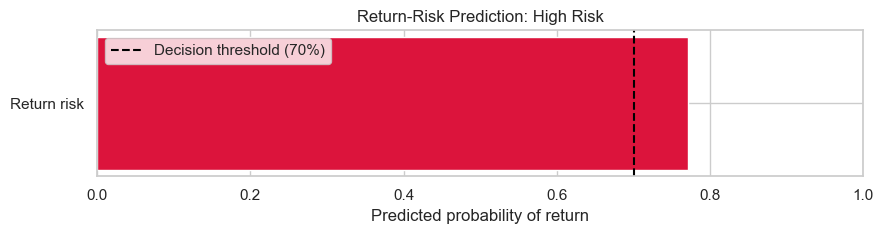

In [7]:
probability = sample_prediction["return_probability"]

plt.figure(figsize=(9, 2.5))

plt.barh(
    ["Return risk"],
    [probability],
    color=(
        "crimson"
        if probability >= decision_threshold
        else "steelblue"
    ),
)

plt.axvline(
    decision_threshold,
    color="black",
    linestyle="--",
    label=(
        f"Decision threshold "
        f"({decision_threshold:.0%})"
    ),
)

plt.xlim(0, 1)
plt.xlabel("Predicted probability of return")
plt.title(
    f"Return-Risk Prediction: "
    f"{sample_prediction['risk_level']} Risk"
)
plt.legend()
plt.tight_layout()
plt.show()

# Demonstrate Batch Predictions


In [8]:
batch_sample_df = demo_source_df.sample(
    n=5,
    random_state=42,
)

batch_input_df = batch_sample_df[
    feature_columns
].copy()

batch_prediction_df = predict_return_risk(
    batch_input_df,
    model_artifact,
)

batch_results_df = pd.concat(
    [
        batch_sample_df[
            ["order_id", "order_timestamp"]
        ].reset_index(drop=True),
        batch_prediction_df,
    ],
    axis=1,
)

batch_results_df = batch_results_df.sort_values(
    "return_probability",
    ascending=False,
)

display(batch_results_df)

,order_id,order_timestamp,return_probability,risk_level,predicted_return
4,ORD-632269,2024-11-05 15:54:24,0.9723,High,1
0,ORD-324554,2023-02-28 00:09:54,0.7714,High,1
3,ORD-316527,2023-03-29 03:15:18,0.4199,Medium,0
2,ORD-376736,2022-08-27 11:41:01,0.0291,Low,0
1,ORD-769711,2024-11-06 14:38:59,0.0106,Low,0


# Prediction Input Contract


In [9]:
prediction_contract_df = pd.DataFrame({
    "feature_name": feature_columns,
    "feature_type": [
        (
            "categorical"
            if column in categorical_columns
            else "numeric"
        )
        for column in feature_columns
    ],
})

display(prediction_contract_df)

print(
    "Total required model-ready features: "
    f"{len(prediction_contract_df)}"
)

,feature_name,feature_type
0,order_month,numeric
1,order_day_of_week,numeric
2,order_hour,numeric
3,order_quarter,numeric
4,sales_channel,categorical
5,payment_method,categorical
6,currency,categorical
7,shipping_method,categorical
8,warehouse,categorical
9,marketing_channel,categorical


Total required model-ready features: 50
